# House price predictor

In [ ]:
# imp libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#data loading
df = pd.read_csv('/content/Housing.csv')

understanding the data

In [ ]:
df.sample(5)

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

EDA

In [ ]:
df.columns

In [ ]:
df['price'].mean()

In [ ]:
df['furnishingstatus'].value_counts()

In [ ]:
df['price'].describe()

In [ ]:
import seaborn as sns
sns.distplot(df['price'])

In [ ]:
from sklearn.preprocessing import  PowerTransformer
# pt = PowerTransformer(method='yeo-johnson')
# df['price'] = pt.fit_transform(df[['price']])

from sklearn.preprocessing import FunctionTransformer

# Use log1p to handle potential zeros in the dataset
log_transformer = FunctionTransformer(np.log1p)
df['price'] = log_transformer.transform(df['price'])

In [ ]:
sns.distplot(df['price'])

### Feature Engineering: Creating new features

We will create new features to capture more complex relationships in the data:
1.  **Polynomial Features**: Create interaction terms between key numerical features.
2.  **Ratio Features**: Create 'area per bedroom' and 'bathrooms per bedroom' as these ratios can be very informative for house pricing.

In [ ]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()

selective_ccolumns = ['mainroad','guestroom','basement', 'hotwaterheating',	'airconditioning','prefarea','furnishingstatus']
for column in selective_ccolumns:
  df[column] = le.fit_transform(df[column])

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create some interaction terms using PolynomialFeatures
# Considering 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'
poly = PolynomialFeatures(degree=2, include_bias=False)

# Select the features for polynomial expansion
poly_features_df = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
poly_features = poly.fit_transform(poly_features_df)

# Get feature names for the new polynomial features
poly_feature_names = poly.get_feature_names_out(poly_features_df.columns)

# Create a DataFrame for the new polynomial features
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names, index=df.index)


# Identify columns that are new (not present in the original df's feature columns)
existing_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price'] + selective_ccolumns
new_poly_columns = [col for col in poly_feature_names if col not in df.columns and col != 'price']

# Filter poly_df to only include the new interaction terms
poly_df_filtered = poly_df[new_poly_columns]

# Merge the new polynomial features with the original dataframe
df = pd.concat([df, poly_df_filtered], axis=1)

print("DataFrame after adding polynomial features:")
print(df.head())

# Add domain-specific ratio features
df['area_per_bedroom'] = df['area'] / df['bedrooms'].replace(0, 1) # Avoid division by zero
df['bathrooms_per_bedroom'] = df['bathrooms'] / df['bedrooms'].replace(0, 1) # Avoid division by zero

print("\nDataFrame after adding ratio features:")
print(df.head())

# Display new info
print("\nUpdated DataFrame info:")
df.info()

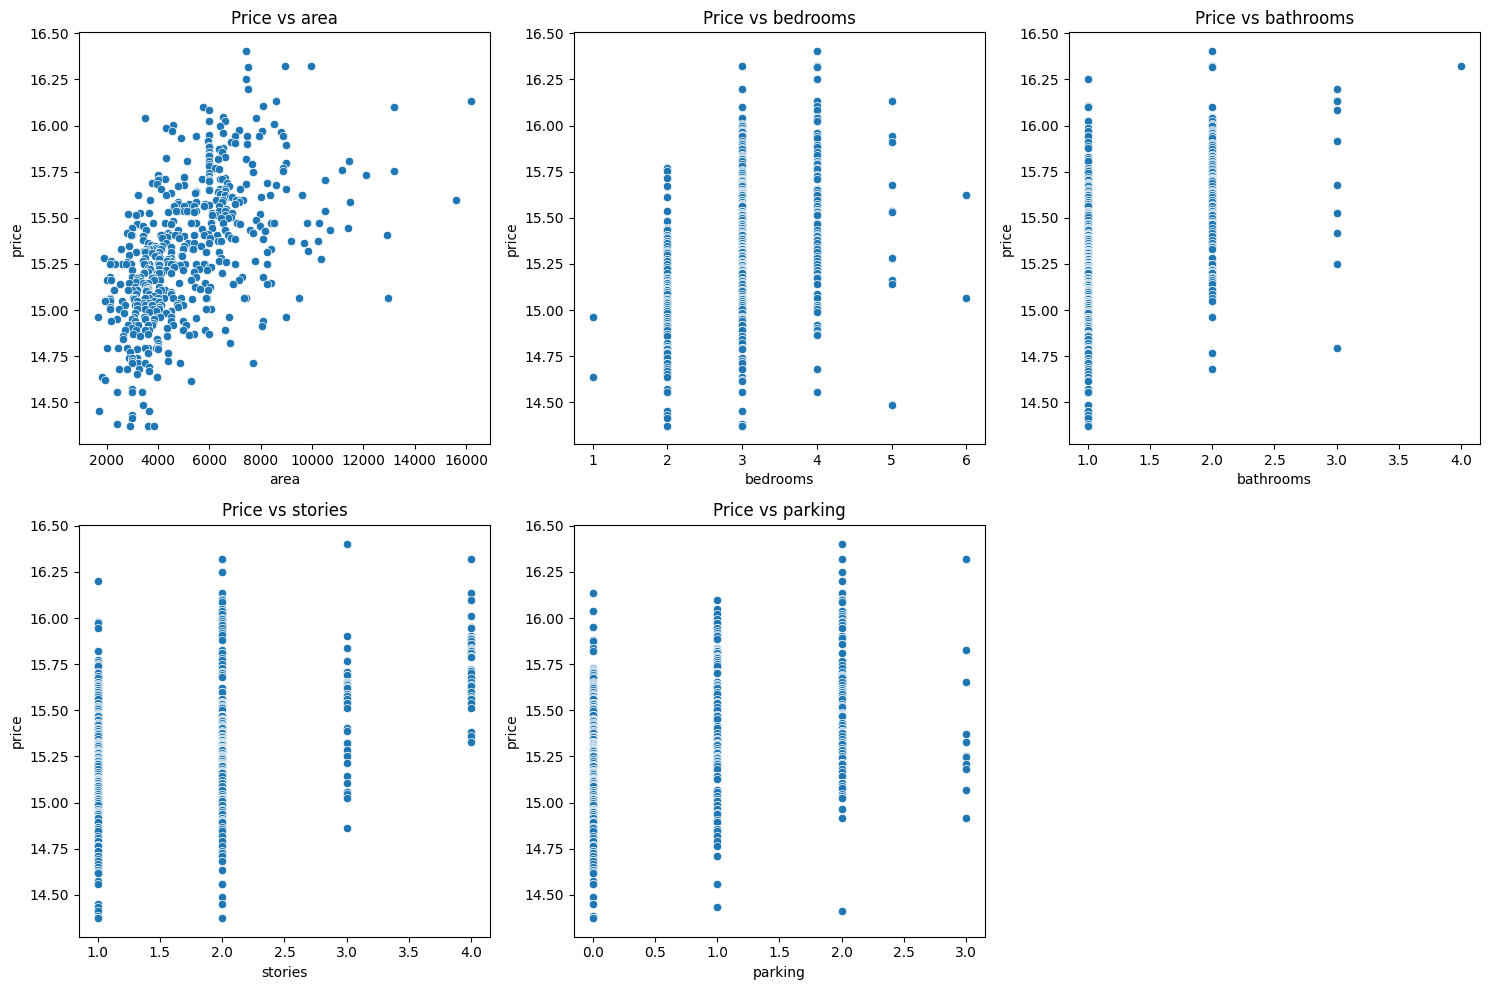

In [ ]:
# Visualizing the relationship between 'price' and numerical features
numerical_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=feature, y='price', data=df)
    plt.title(f'Price vs {feature}')
plt.tight_layout()
plt.show()

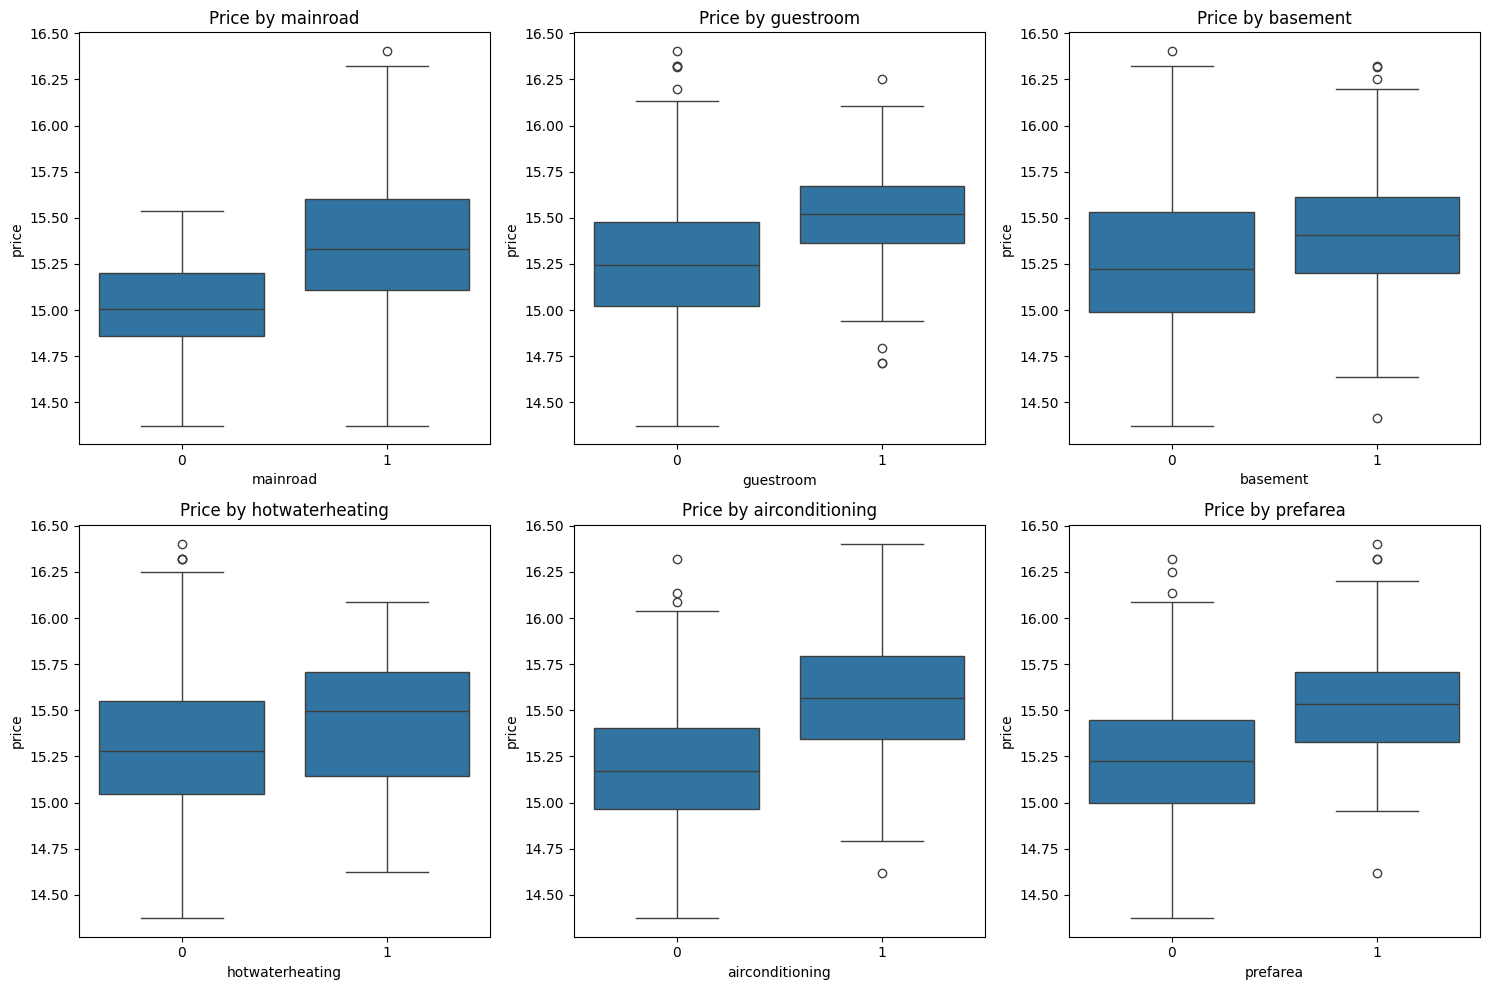

In [ ]:
# Visualizing the relationship between 'price' and (binary encoded) categorical features
encoded_categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(encoded_categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=feature, y='price', data=df)
    plt.title(f'Price by {feature}')
plt.tight_layout()
plt.show()


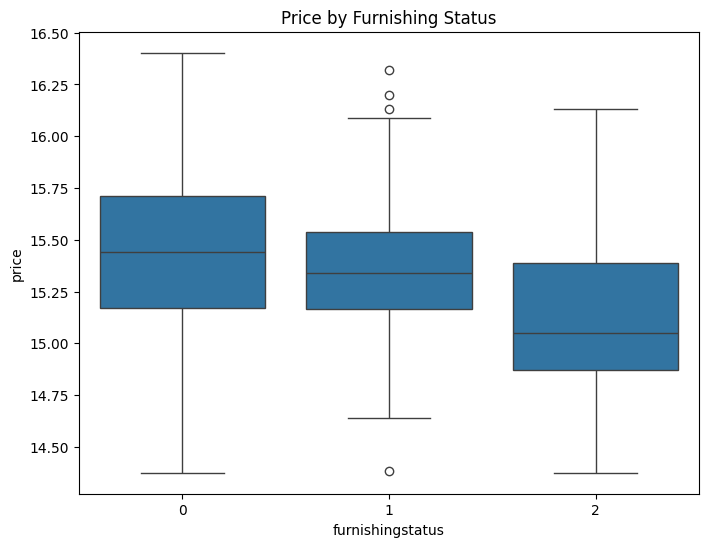

In [ ]:
# Visualizing the relationship between 'price' and 'furnishingstatus' (object type)
plt.figure(figsize=(8, 6))
sns.boxplot(x='furnishingstatus', y='price', data=df)
plt.title('Price by Furnishing Status')
plt.show()

<Axes: >

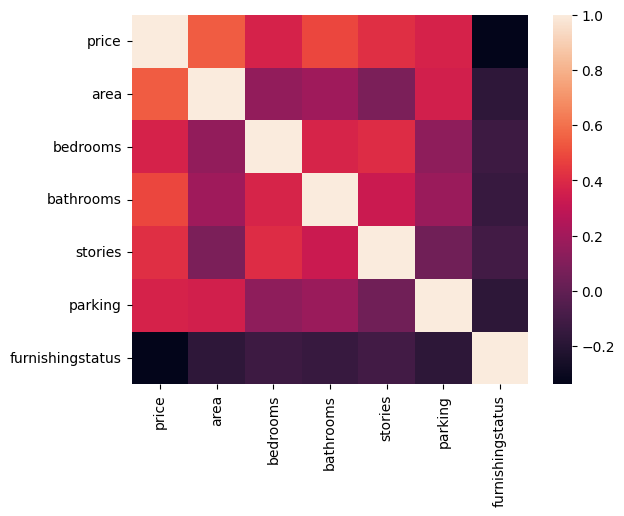

In [ ]:
import seaborn as sns

sns.heatmap(df[['price','area',	'bedrooms',	'bathrooms','stories','parking','furnishingstatus']].corr())

model training and evaluation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score , accuracy_score
from sklearn.model_selection import train_test_split , GridSearchCV , RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('price',axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
mod1 = LinearRegression()
mod1.fit(X_train,y_train)
y_pred = mod1.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.06777728689927022
0.648983562484964


In [ ]:
from sklearn.svm import SVR

params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

mod2 = SVR()
mod2.fit(X_train,y_train)
y_pred = mod2.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

print('grid results are ....')

g1 = GridSearchCV(mod2,param_grid=params,cv=5)
g1.fit(X_train,y_train)
y_pred = g1.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

print(g1.best_params_)
print(g1.best_score_)

0.07722665363648488
0.6000455892993497
grid results are ....
0.0693764166520031
0.6407017197820712
{'C': 0.01, 'epsilon': 0.01, 'kernel': 'linear'}
0.6784738927480973


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

mod3 = KNeighborsRegressor()
mod3.fit(X_train,y_train)
y_pred = mod3.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))


g2 = GridSearchCV(mod3,param_grid=params,cv=5)
g2.fit(X_train,y_train)

print('grid results are ....')
y_pred = g2.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

print(g2.best_params_)
print(g2.best_score_)

0.07804011587827825
0.5958326939293763
grid results are ....
0.07966387540180847
0.587423294418036
{'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
0.6248763541985491


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}

mod4 = DecisionTreeRegressor()
mod4.fit(X_train,y_train)
y_pred = mod4.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))


g3 = GridSearchCV(mod4 , param_grid=params , cv=5)
g3.fit(X_train,y_train)
print('grid results are ....')
y_pred = g3.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

print(g3.best_params_)
print(g3.best_score_)

0.11082851257809244
0.4260226184906313
grid results are ....
0.09308580389401021
0.5179115488252076
{'criterion': 'squared_error', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}
0.5357459700069898


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [10, 50, 100, 200],
    'max_features': ['sqrt', 'log2'], # Removed 'auto' as it's deprecated
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
}

mod5 = RandomForestRegressor(n_estimators=12, random_state=42)
mod5.fit(X_train,y_train)
y_pred = mod5.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))


g4 = RandomizedSearchCV(mod5 , param_distributions=params , cv=5)
g4.fit(X_train,y_train)
print('grid results are ....')
y_pred = g4.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

print(g4.best_params_)
print(g4.best_score_)

0.07711108561275294
0.6006441124600854
grid results are ....
0.0757958120611291
0.6074558728236258
{'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 10}
0.6320235676323998


higher ensmble techinques

In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Bagging with Linear Regression
print("\n--- Bagging with Linear Regression ---")
bag_lin_reg = BaggingRegressor(estimator=LinearRegression(), random_state=42)
bag_lin_reg.fit(X_train, y_train)
y_pred_lin_reg_bag = bag_lin_reg.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred_lin_reg_bag)}")
print(f"R2 Score: {r2_score(y_test, y_pred_lin_reg_bag)}")

# Bagging with SVR (using best params from previous GridSearchCV)
# Best params for SVR were {'C': 1, 'epsilon': 0.01, 'kernel': 'linear'}
print("\n--- Bagging with SVR ---")
bag_svr = BaggingRegressor(estimator=SVR(C=1, epsilon=0.01, kernel='linear'), random_state=42)
bag_svr.fit(X_train, y_train)
y_pred_svr_bag = bag_svr.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred_svr_bag)}")
print(f"R2 Score: {r2_score(y_test, y_pred_svr_bag)}")

# Bagging with RandomForestRegressor (using best params from previous RandomizedSearchCV)
# Best params for RandomForest were {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 10}
print("\n--- Bagging with RandomForestRegressor ---")
bag_rf = BaggingRegressor(estimator=RandomForestRegressor(n_estimators=200, min_samples_split=2, max_features='log2', max_depth=10, random_state=42), random_state=42)
bag_rf.fit(X_train, y_train)
y_pred_rf_bag = bag_rf.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred_rf_bag)}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf_bag)}")


--- Bagging with Linear Regression ---
MSE: 0.06746876111034622
R2 Score: 0.6505814078438461

--- Bagging with SVR ---
MSE: 0.06908657568948035
R2 Score: 0.6422027970125874

--- Bagging with RandomForestRegressor ---
MSE: 0.07493258997042808
R2 Score: 0.6119264728863352


In [ ]:
!pip install optuna

In [ ]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- Gradient Boosting Regressor with Optuna ---
print("\n--- Gradient Boosting Regressor with Optuna ---")

def objective_gbr(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    gbr = GradientBoostingRegressor(**params, random_state=42)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    return r2_score(y_test, y_pred)

study_gbr = optuna.create_study(direction='maximize')
study_gbr.optimize(objective_gbr, n_trials=50, show_progress_bar=True)

print("Best parameters for GBR:", study_gbr.best_params)
print("Best R2 Score for GBR:", study_gbr.best_value)

# Train GBR with best parameters
best_gbr = GradientBoostingRegressor(**study_gbr.best_params, random_state=42)
best_gbr.fit(X_train, y_train)
y_pred_best_gbr = best_gbr.predict(X_test)
print(f"Final GBR MSE: {mean_squared_error(y_test, y_pred_best_gbr)}")
print(f"Final GBR R2 Score: {r2_score(y_test, y_pred_best_gbr)}")

# --- XGBoost Regressor with Optuna ---
print("\n--- XGBoost Regressor with Optuna ---")

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 0.5)
    }

    xgb = XGBRegressor(**params, random_state=42, use_label_encoder=False, eval_metric='rmse')
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    return r2_score(y_test, y_pred)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print("Best parameters for XGBoost:", study_xgb.best_params)
print("Best R2 Score for XGBoost:", study_xgb.best_value)

# Train XGBoost with best parameters
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, use_label_encoder=False, eval_metric='rmse')
best_xgb.fit(X_train, y_train)
y_pred_best_xgb = best_xgb.predict(X_test)
print(f"Final XGBoost MSE: {mean_squared_error(y_test, y_pred_best_xgb)}")
print(f"Final XGBoost R2 Score: {r2_score(y_test, y_pred_best_xgb)}")

[I 2026-05-22 13:18:04,735] A new study created in memory with name: no-name-15dc7fbe-05f3-4935-b682-8a573d25a2d8



--- Gradient Boosting Regressor with Optuna ---


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-22 13:18:05,138] Trial 0 finished with value: 0.6547533847995446 and parameters: {'n_estimators': 281, 'learning_rate': 0.04328627774597627, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 7, 'subsample': 0.7071303414140573, 'max_features': 'log2'}. Best is trial 0 with value: 0.6547533847995446.
[I 2026-05-22 13:18:06,167] Trial 1 finished with value: 0.6519500768123869 and parameters: {'n_estimators': 776, 'learning_rate': 0.033124846507962845, 'max_depth': 10, 'min_samples_split': 16, 'min_samples_leaf': 15, 'subsample': 0.8787701346681331, 'max_features': 'log2'}. Best is trial 0 with value: 0.6547533847995446.
[I 2026-05-22 13:18:07,290] Trial 2 finished with value: 0.6366397855129071 and parameters: {'n_estimators': 657, 'learning_rate': 0.014273961932353385, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 2, 'subsample': 0.8510390406367327, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6547533847995446.
[I 2026-05-22 13:18:07,567] Tria

[I 2026-05-22 13:18:40,699] A new study created in memory with name: no-name-ce1db5aa-c720-4f57-ab0a-bc83f30c81ef


...

[I 2026-05-22 13:18:51,634] Trial 45 finished with value: 0.6585956695862945 and parameters: {'n_estimators': 629, 'learning_rate': 0.040443909598715334, 'max_depth': 8, 'subsample': 0.6488459374310324, 'colsample_bytree': 0.9610707931751983, 'gamma': 0.08663214522333826, 'reg_alpha': 0.2505054988686309, 'reg_lambda': 0.1314675555940066}. Best is trial 22 with value: 0.6801204867960331.
[I 2026-05-22 13:18:51,784] Trial 46 finished with value: 0.6511229308220658 and parameters: {'n_estimators': 332, 'learning_rate': 0.07557903739003044, 'max_depth': 7, 'subsample': 0.7435996944296651, 'colsample_bytree': 0.8354534755552611, 'gamma': 0.12571374048201012, 'reg_alpha': 0.07291527598837255, 'reg_lambda': 0.0708951435533904}. Best is trial 22 with value: 0.6801204867960331.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:18:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:18:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-05-22 13:18:51,923] Trial 47 finished with value: 0.6385687349409075 and parameters: {'n_estimators': 391, 'learning_rate': 0.29756931731227915, 'max_depth': 8, 'subsample': 0.7779515134755467, 'colsample_bytree': 0.8197494015236036, 'gamma': 0.16349226895849225, 'reg_alpha': 0.12318831001333092, 'reg_lambda': 0.02488379369640037}. Best is trial 22 with value: 0.6801204867960331.
[I 2026-05-22 13:18:52,100] Trial 48 finished with value: 0.6716701090358286 and parameters: {'n_estimators': 536, 'learning_rate': 0.1453472461294193, 'max_depth': 9, 'subsample': 0.9301538298670127, 'colsample_bytree': 0.8707014787627182, 'gamma': 0.0416104923044463, 'reg_alpha': 0.22373465308124632, 'reg_lambda': 0.45329422713665923}. Best is trial 22 with value: 0.6801204867960331.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:18:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:18:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-05-22 13:18:52,290] Trial 49 finished with value: 0.6521935742857075 and parameters: {'n_estimators': 600, 'learning_rate': 0.18545081850041029, 'max_depth': 9, 'subsample': 0.9647973589821778, 'colsample_bytree': 0.8725334912753615, 'gamma': 0.03932387693619274, 'reg_alpha': 0.23332095650360796, 'reg_lambda': 0.42698197885911826}. Best is trial 22 with value: 0.6801204867960331.
Best parameters for XGBoost: {'n_estimators': 279, 'learning_rate': 0.06518709308453906, 'max_depth': 8, 'subsample': 0.6384755134869866, 'colsample_bytree': 0.9299426580946597, 'gamma': 0.08660290206113971, 'reg_alpha': 0.1850771298481588, 'reg_lambda': 0.09271926684862575}
Best R2 Score for XGBoost: 0.6801204867960331
Final XGBoost MSE: 0.06176510049816532
Final XGBoost R2 Score: 0.6801204867960331


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Identify the best performing models from previous steps
# Based on the R2 scores:
# best_gbr (from Optuna) - R2: 0.6792597718213842
# best_xgb (from Optuna) - R2: 0.6724623725791333 (assuming this was printed based on the best_value)
# bag_lin_reg - R2: 0.6505814078438461


best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, eval_metric='rmse')
best_xgb.fit(X_train, y_train)


estimators = [
    ('gbr', best_gbr),
    ('xgb', best_xgb),
    ('bag_lin_reg', bag_lin_reg)
]

# Initialize StackingRegressor with Linear Regression as the meta-regressor
stk_regressor = StackingRegressor(estimators=estimators, final_estimator=LinearRegression(), cv=5)

# Train the Stacking Regressor
stk_regressor.fit(X_train, y_train)

# Make predictions
y_pred_stacked = stk_regressor.predict(X_test)

# Evaluate the Stacking Regressor
mse_stacked = mean_squared_error(y_test, y_pred_stacked)
r2_stacked = r2_score(y_test, y_pred_stacked)

print("--- Stacking Regressor Results ---")
print(f"Mean Squared Error (Stacked): {mse_stacked}")
print(f"R2 Score (Stacked): {r2_stacked}")


--- Stacking Regressor Results ---
Mean Squared Error (Stacked): 0.06244419649338
R2 Score (Stacked): 0.6766034699917864


### Principal Component Analysis (PCA)

We will now apply PCA to reduce the dimensionality of our features and observe its effect on model performance, using Linear Regression as a baseline model for comparison.

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA to retain 95% of variance
pca = PCA(n_components=0.95)

# Fit PCA on the training data and transform both training and testing data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features after PCA: {X_train_pca.shape[1]}")


Original number of features: 29
Reduced number of features after PCA: 11


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train a Linear Regression model on PCA-transformed data
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

# Make predictions on PCA-transformed test data
y_pred_lr_pca = lr_pca.predict(X_test_pca)

# Evaluate the Linear Regression model with PCA
mse_lr_pca = mean_squared_error(y_test, y_pred_lr_pca)
r2_lr_pca = r2_score(y_test, y_pred_lr_pca)

print("--- Linear Regression with PCA Results ---")
print(f"Mean Squared Error (LR + PCA): {mse_lr_pca}")
print(f"R2 Score (LR + PCA): {r2_lr_pca}")


--- Linear Regression with PCA Results ---
Mean Squared Error (LR + PCA): 0.0674220607445661
R2 Score (LR + PCA): 0.6508232675696737


In [ ]:
print("\n--- Evaluating other models with PCA features ---")

# Re-evaluate SVR with PCA
print("\n--- SVR (Optimized) with PCA ---")
svr_pca = g1.best_estimator_
svr_pca.fit(X_train_pca, y_train)
y_pred_svr_pca = svr_pca.predict(X_test_pca)
mse_svr_pca = mean_squared_error(y_test, y_pred_svr_pca)
r2_svr_pca = r2_score(y_test, y_pred_svr_pca)
print(f"Mean Squared Error (SVR + PCA): {mse_svr_pca}")
print(f"R2 Score (SVR + PCA): {r2_svr_pca}")



--- Evaluating other models with PCA features ---

--- SVR (Optimized) with PCA ---
Mean Squared Error (SVR + PCA): 0.06987181669674643
R2 Score (SVR + PCA): 0.638136058528781


In [ ]:
# Re-evaluate KNN with PCA
print("\n--- KNN (Optimized) with PCA ---")
knn_pca = g2.best_estimator_
knn_pca.fit(X_train_pca, y_train)
y_pred_knn_pca = knn_pca.predict(X_test_pca)
mse_knn_pca = mean_squared_error(y_test, y_pred_knn_pca)
r2_knn_pca = r2_score(y_test, y_pred_knn_pca)
print(f"Mean Squared Error (KNN + PCA): {mse_knn_pca}")
print(f"R2 Score (KNN + PCA): {r2_knn_pca}")


--- KNN (Optimized) with PCA ---
Mean Squared Error (KNN + PCA): 0.08109666752606096
R2 Score (KNN + PCA): 0.5800029090623613


In [ ]:
# Re-evaluate Decision Tree with PCA
print("\n--- Decision Tree (Optimized) with PCA ---")
dt_pca = g3.best_estimator_
dt_pca.fit(X_train_pca, y_train)
y_pred_dt_pca = dt_pca.predict(X_test_pca)
mse_dt_pca = mean_squared_error(y_test, y_pred_dt_pca)
r2_dt_pca = r2_score(y_test, y_pred_dt_pca)
print(f"Mean Squared Error (DT + PCA): {mse_dt_pca}")
print(f"R2 Score (DT + PCA): {r2_dt_pca}")



--- Decision Tree (Optimized) with PCA ---
Mean Squared Error (DT + PCA): 0.1209099981291154
R2 Score (DT + PCA): 0.3738109218460214


In [ ]:
# Re-evaluate Random Forest with PCA
print("\n--- Random Forest (Optimized) with PCA ---")
rf_pca = g4.best_estimator_
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
mse_rf_pca = mean_squared_error(y_test, y_pred_rf_pca)
r2_rf_pca = r2_score(y_test, y_pred_rf_pca)
print(f"Mean Squared Error (RF + PCA): {mse_rf_pca}")
print(f"R2 Score (RF + PCA): {r2_rf_pca}")


--- Random Forest (Optimized) with PCA ---
Mean Squared Error (RF + PCA): 0.08248408489536514
R2 Score (RF + PCA): 0.5728175181357015


In [ ]:
# Re-evaluate Bagging with Linear Regression with PCA
print("\n--- Bagging with Linear Regression with PCA ---")
bag_lin_reg_pca = BaggingRegressor(estimator=LinearRegression(), random_state=42)
bag_lin_reg_pca.fit(X_train_pca, y_train)
y_pred_bag_lin_reg_pca = bag_lin_reg_pca.predict(X_test_pca)
mse_bag_lin_reg_pca = mean_squared_error(y_test, y_pred_bag_lin_reg_pca)
r2_bag_lin_reg_pca = r2_score(y_test, y_pred_bag_lin_reg_pca)
print(f"Mean Squared Error (Bagging LR + PCA): {mse_bag_lin_reg_pca}")
print(f"R2 Score (Bagging LR + PCA): {r2_bag_lin_reg_pca}")


--- Bagging with Linear Regression with PCA ---
Mean Squared Error (Bagging LR + PCA): 0.06793613492399606
R2 Score (Bagging LR + PCA): 0.6481608935600713


In [ ]:
# Re-evaluate Bagging with SVR with PCA
print("\n--- Bagging with SVR (Optimized) with PCA ---")
bag_svr_pca = BaggingRegressor(estimator=SVR(**g1.best_params_), random_state=42)
bag_svr_pca.fit(X_train_pca, y_train)
y_pred_bag_svr_pca = bag_svr_pca.predict(X_test_pca)
mse_bag_svr_pca = mean_squared_error(y_test, y_pred_bag_svr_pca)
r2_bag_svr_pca = r2_score(y_test, y_pred_bag_svr_pca)
print(f"Mean Squared Error (Bagging SVR + PCA): {mse_bag_svr_pca}")
print(f"R2 Score (Bagging SVR + PCA): {r2_bag_svr_pca}")



--- Bagging with SVR (Optimized) with PCA ---
Mean Squared Error (Bagging SVR + PCA): 0.07051947226650204
R2 Score (Bagging SVR + PCA): 0.6347818706993057


In [ ]:
# Re-evaluate Bagging with RandomForestRegressor with PCA
print("\n--- Bagging with Random Forest (Optimized) with PCA ---")
bag_rf_pca = BaggingRegressor(estimator=RandomForestRegressor(**g4.best_params_, random_state=42), random_state=42)
bag_rf_pca.fit(X_train_pca, y_train)
y_pred_bag_rf_pca = bag_rf_pca.predict(X_test_pca)
mse_bag_rf_pca = mean_squared_error(y_test, y_pred_bag_rf_pca)
r2_bag_rf_pca = r2_score(y_test, y_pred_bag_rf_pca)
print(f"Mean Squared Error (Bagging RF + PCA): {mse_bag_rf_pca}")
print(f"R2 Score (Bagging RF + PCA): {r2_bag_rf_pca}")


--- Bagging with Random Forest (Optimized) with PCA ---
Mean Squared Error (Bagging RF + PCA): 0.08352845734230967
R2 Score (Bagging RF + PCA): 0.5674087460744923


In [ ]:
# Re-evaluate Gradient Boosting Regressor with PCA
print("\n--- Gradient Boosting Regressor (Optimized) with PCA ---")
best_gbr_pca = GradientBoostingRegressor(**study_gbr.best_params, random_state=42)
best_gbr_pca.fit(X_train_pca, y_train)
y_pred_best_gbr_pca = best_gbr_pca.predict(X_test_pca)
mse_best_gbr_pca = mean_squared_error(y_test, y_pred_best_gbr_pca)
r2_best_gbr_pca = r2_score(y_test, y_pred_best_gbr_pca)
print(f"Mean Squared Error (GBR + PCA): {mse_best_gbr_pca}")
print(f"R2 Score (GBR + PCA): {r2_best_gbr_pca}")



--- Gradient Boosting Regressor (Optimized) with PCA ---
Mean Squared Error (GBR + PCA): 0.07357217807879174
R2 Score (GBR + PCA): 0.6189720032933722


In [ ]:
# Re-evaluate XGBoost Regressor with PCA
print("\n--- XGBoost Regressor (Optimized) with PCA ---")
best_xgb_pca = XGBRegressor(**study_xgb.best_params, random_state=42, eval_metric='rmse')
best_xgb_pca.fit(X_train_pca, y_train)
y_pred_best_xgb_pca = best_xgb_pca.predict(X_test_pca)
mse_best_xgb_pca = mean_squared_error(y_test, y_pred_best_xgb_pca)
r2_best_xgb_pca = r2_score(y_test, y_pred_best_xgb_pca)
print(f"Mean Squared Error (XGB + PCA): {mse_best_xgb_pca}")
print(f"R2 Score (XGB + PCA): {r2_best_xgb_pca}")


--- XGBoost Regressor (Optimized) with PCA ---
Mean Squared Error (XGB + PCA): 0.07726273852083608
R2 Score (XGB + PCA): 0.5998587068180264


In [ ]:
# Re-evaluate Stacking Regressor with PCA
print("\n--- Stacking Regressor with PCA ---")
# Create new base estimators for stacking using PCA-transformed data
estimators_pca = [
    ('gbr', best_gbr_pca),
    ('xgb', best_xgb_pca),
    ('bag_lin_reg', bag_lin_reg_pca)
]
stk_regressor_pca = StackingRegressor(estimators=estimators_pca, final_estimator=LinearRegression(), cv=5)
stk_regressor_pca.fit(X_train_pca, y_train)
y_pred_stacked_pca = stk_regressor_pca.predict(X_test_pca)
mse_stacked_pca = mean_squared_error(y_test, y_pred_stacked_pca)
r2_stacked_pca = r2_score(y_test, y_pred_stacked_pca)
print(f"Mean Squared Error (Stacked + PCA): {mse_stacked_pca}")
print(f"R2 Score (Stacked + PCA): {r2_stacked_pca}")


--- Stacking Regressor with PCA ---
Mean Squared Error (Stacked + PCA): 0.06728252905799192
R2 Score (Stacked + PCA): 0.6515458977867037


In [ ]:
# Re-instantiate and re-fit the best estimators for 'No PCA' evaluation
# This is necessary because the original best_estimator_ objects might have been re-fitted with PCA data.

# SVR (Optimized)
best_svr_no_pca = SVR(**g1.best_params_)
best_svr_no_pca.fit(X_train, y_train)
r2_g1_no_pca_calc = r2_score(y_test, best_svr_no_pca.predict(X_test))

# K-Nearest Neighbors Regressor (Optimized)
best_knn_no_pca = KNeighborsRegressor(**g2.best_params_)
best_knn_no_pca.fit(X_train, y_train)
r2_g2_no_pca_calc = r2_score(y_test, best_knn_no_pca.predict(X_test))

# Decision Tree Regressor (Optimized)
best_dt_no_pca = DecisionTreeRegressor(**g3.best_params_)
best_dt_no_pca.fit(X_train, y_train)
r2_g3_no_pca_calc = r2_score(y_test, best_dt_no_pca.predict(X_test))

# Random Forest Regressor (Optimized)
# Ensure random_state is passed if not in best_params_ or it's default
best_rf_no_pca = RandomForestRegressor(**g4.best_params_, random_state=42)
best_rf_no_pca.fit(X_train, y_train)
r2_g4_no_pca_calc = r2_score(y_test, best_rf_no_pca.predict(X_test))

model_performance = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVR (Optimized)',
        'K-Nearest Neighbors Regressor (Optimized)',
        'Decision Tree Regressor (Optimized)',
        'Random Forest Regressor (Optimized)',
        'Bagging with Linear Regression',
        'Bagging with SVR (Optimized)',
        'Bagging with Random Forest (Optimized)',
        'Gradient Boosting Regressor (Optuna)',
        'XGBoost Regressor (Optuna)',
        'Stacking Regressor'
    ],
    'R2 Score (No PCA)': [
        r2_score(y_test, mod1.predict(X_test)),
        r2_g1_no_pca_calc,
        r2_g2_no_pca_calc,
        r2_g3_no_pca_calc,
        r2_g4_no_pca_calc,
        r2_score(y_test, bag_lin_reg.predict(X_test)),
        r2_score(y_test, bag_svr.predict(X_test)),
        r2_score(y_test, bag_rf.predict(X_test)),
        study_gbr.best_value,
        study_xgb.best_value,
        r2_stacked
    ],
    'R2 Score (With PCA)': [
        r2_lr_pca,
        r2_svr_pca,
        r2_knn_pca,
        r2_dt_pca,
        r2_rf_pca,
        r2_bag_lin_reg_pca,
        r2_bag_svr_pca,
        r2_bag_rf_pca,
        r2_best_gbr_pca,
        r2_best_xgb_pca,
        r2_stacked_pca
    ]
})

# Sort by R2 Score (No PCA) for better comparison
model_performance = model_performance.sort_values(by='R2 Score (No PCA)', ascending=False).reset_index(drop=True)

print(model_performance.to_markdown(index=False))


| Model                                     |   R2 Score (No PCA) |   R2 Score (With PCA) |
|:------------------------------------------|--------------------:|----------------------:|
| XGBoost Regressor (Optuna)                |            0.68012  |              0.599859 |
| Gradient Boosting Regressor (Optuna)      |            0.67926  |              0.618972 |
| Stacking Regressor                        |            0.676603 |              0.651546 |
| Bagging with Linear Regression            |            0.650581 |              0.648161 |
| Linear Regression                         |            0.648984 |              0.650823 |
| Bagging with SVR (Optimized)              |            0.642203 |              0.634782 |
| SVR (Optimized)                           |            0.640702 |              0.638136 |
| Bagging with Random Forest (Optimized)    |            0.611926 |              0.567409 |
| Random Forest Regressor (Optimized)       |            0.607456 |             

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("\n--- More Extensive XGBoost Regressor Tuning with Optuna (Re-run) ---")

def objective_xgb_extended(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000), # Increased range
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True), # Wider range
        'max_depth': trial.suggest_int('max_depth', 3, 15), # Increased range
        'subsample': trial.suggest_float('subsample', 0.5, 1.0), # Wider range
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # Wider range
        'gamma': trial.suggest_float('gamma', 0.0, 1.0), # Wider range
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0), # Wider range
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0)
    }

    xgb = XGBRegressor(**params, random_state=42, eval_metric='rmse', use_label_encoder=False)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    return r2_score(y_test, y_pred)

# Increase n_trials for a more thorough search
study_xgb_extended = optuna.create_study(direction='maximize')
study_xgb_extended.optimize(objective_xgb_extended, n_trials=100, show_progress_bar=True)

print("Best parameters for Extended XGBoost Tuning:", study_xgb_extended.best_params)
print("Best R2 Score for Extended XGBoost Tuning:", study_xgb_extended.best_value)

# Train XGBoost with best parameters from extended tuning
best_xgb_extended = XGBRegressor(**study_xgb_extended.best_params, random_state=42, eval_metric='rmse', use_label_encoder=False)
best_xgb_extended.fit(X_train, y_train)
y_pred_best_xgb_extended = best_xgb_extended.predict(X_test)
print(f"Final Extended XGBoost MSE: {mean_squared_error(y_test, y_pred_best_xgb_extended)}")
print(f"Final Extended XGBoost R2 Score: {r2_score(y_test, y_pred_best_xgb_extended)}")


[I 2026-05-22 13:43:17,468] A new study created in memory with name: no-name-b333e418-21d8-4072-9f5a-469ad12152f8



--- More Extensive XGBoost Regressor Tuning with Optuna (Re-run) ---


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:43:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-05-22 13:43:17,816] Trial 0 finished with value: 0.6612308841078678 and parameters: {'n_estimators': 1534, 'learning_rate': 0.3251775678606678, 'max_depth': 12, 'subsample': 0.5484973614392019, 'colsample_bytree': 0.8425480081609422, 'gamma': 0.44259192587524354, 'reg_alpha': 0.5431552630933788, 'reg_lambda': 0.5714196198587598}. Best is trial 0 with value: 0.6612308841078678.


...

[I 2026-05-22 13:44:04,936] Trial 98 finished with value: 0.691118519303713 and parameters: {'n_estimators': 1949, 'learning_rate': 0.47686627074849913, 'max_depth': 14, 'subsample': 0.5572110457882452, 'colsample_bytree': 0.9158884812474805, 'gamma': 0.14649838994961845, 'reg_alpha': 0.8141376998507378, 'reg_lambda': 0.5748342802981574}. Best is trial 98 with value: 0.691118519303713.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:44:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-05-22 13:44:05,358] Trial 99 finished with value: 0.6734393861652568 and parameters: {'n_estimators': 1929, 'learning_rate': 0.4559709999994407, 'max_depth': 12, 'subsample': 0.5550420331198392, 'colsample_bytree': 0.9116398023791191, 'gamma': 0.14390937545027835, 'reg_alpha': 0.9211064847626305, 'reg_lambda': 0.4413622660265457}. Best is trial 98 with value: 0.691118519303713.
Best parameters for Extended XGBoost Tuning: {'n_estimators': 1949, 'learning_rate': 0.47686627074849913, 'max_depth': 14, 'subsample': 0.5572110457882452, 'colsample_bytree': 0.9158884812474805, 'gamma': 0.14649838994961845, 'reg_alpha': 0.8141376998507378, 'reg_lambda': 0.5748342802981574}
Best R2 Score for Extended XGBoost Tuning: 0.691118519303713


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:44:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Final Extended XGBoost MSE: 0.05964150534724422
Final Extended XGBoost R2 Score: 0.691118519303713
